# 🎵 Music Generation with LSTM Autoencoder

- **Loss**: MSE
- **Representation**: Piano Roll
- **Dataset**: MAESTRO v3.0.0
- **Key Normalization**: Major→C Major, Minor→A Minor
- **Pitch Range**: C3–B5 (MIDI 48–83, 36 pitches)
- **Output**: 10 × 10-second WAV files

In [ ]:
!pip install torch pretty_midi numpy scipy tqdm music21

In [ ]:
import os, glob, random, json, urllib.request, zipfile, warnings
import numpy as np
import pretty_midi
import scipy.io.wavfile as wavfile
from tqdm import tqdm
import music21

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

# ── GPU Setup ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [ ]:
# ── Download MAESTRO MIDI-only dataset (~57 MB) ──
MAESTRO_URL = "https://storage.googleapis.com/magentadata/datasets/maestro/v3.0.0/maestro-v3.0.0-midi.zip"
ZIP_PATH = "maestro-v3.0.0-midi.zip"
EXTRACT_DIR = "maestro-v3.0.0"

if not os.path.exists(EXTRACT_DIR):
    print("Downloading MAESTRO MIDI dataset …")
    urllib.request.urlretrieve(MAESTRO_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")
    os.remove(ZIP_PATH)
    print("Done!")
else:
    print("MAESTRO dataset already present.")

midi_files = sorted(glob.glob(os.path.join(EXTRACT_DIR, "**", "*.mid*"), recursive=True))
print(f"Found {len(midi_files)} MIDI files total.")

MAESTRO dataset already present.
Found 1276 MIDI files total.


In [ ]:
# ── Updated Constants for 36-Pitch Range ──
PITCH_MIN = 48       # C3
PITCH_MAX = 83       # B5
NUM_PITCHES = PITCH_MAX - PITCH_MIN + 1   # 36 pitches
WINDOW_SIZE = 128
FS = 16

In [ ]:
# ── Final Constants Verification (36 pitches) ──
PITCH_MIN = 48       # C3
PITCH_MAX = 83       # B5
NUM_PITCHES = PITCH_MAX - PITCH_MIN + 1 # 36
WINDOW_SIZE = 128
FS = 16

import pandas as pd
csv_path = os.path.join(EXTRACT_DIR, 'maestro-v3.0.0.csv')
df_metadata = pd.read_csv(csv_path)
print(f"Metadata loaded. Ready for 36-pitch pipeline.")

Metadata loaded. Ready for 36-pitch pipeline.


In [ ]:
def process_midi_stages_1_to_4(midi_path):
    """
    Stage 1: Transpose, then extract (T, 36) piano roll
    Stage 2: Binarize
    Stage 3: Segment into non-overlapping windows
    Stage 4: Filter sparse windows
    """
    try:
        # Load MIDI
        mid = pretty_midi.PrettyMIDI(midi_path)

        # Key-based Transposition (Music21)
        transpose_to_target(mid, midi_path)

        # Stage 1: Get roll and slice to 36 pitches (C3-B5)
        roll = mid.get_piano_roll(fs=FS)
        # Slice the pitch axis (indices 48 to 83 inclusive) and transpose to (T, 36)
        roll = roll[PITCH_MIN:PITCH_MAX+1, :].T

        # Stage 2: Binarize (0 or 1)
        roll = (roll > 0).astype(np.float32)

        # Stage 3: Segments
        windows = []
        for i in range(0, roll.shape[0] - WINDOW_SIZE + 1, WINDOW_SIZE):
            win = roll[i : i + WINDOW_SIZE]

            # Stage 4: Density Filter (> 2% active)
            if win.mean() >= 0.02:
                windows.append(win)
        return windows
    except Exception as e:
        return []

In [ ]:
def load_split(split_name, limit=None):
    """Load files belonging to a specific split (train/validation/test)."""
    split_files = df_metadata[df_metadata['split'] == split_name]['midi_filename'].tolist()
    if limit: split_files = split_files[:limit]

    all_windows = []
    for fname in tqdm(split_files, desc=f"Processing {split_name}"):
        full_path = os.path.join(EXTRACT_DIR, fname)
        all_windows.extend(process_midi_stages_1_to_4(full_path))

    return torch.tensor(np.array(all_windows))

# Example: Load a subset of training data
train_data = load_split('train', limit=50)
print(f"\nTrain tensor shape: {train_data.shape}")

Processing train: 100%|██████████| 50/50 [01:15<00:00,  1.51s/it]


Train tensor shape: torch.Size([3520, 128, 36])


In [ ]:
# ── Key detection using music21 ──
# Pitch-class name → MIDI pitch-class number
_PC_MAP = {'C': 0, 'C#': 1, 'D-': 1, 'D': 2, 'D#': 3, 'E-': 3,
           'E': 4, 'F': 5, 'F#': 6, 'G-': 6, 'G': 7, 'G#': 8,
           'A-': 8, 'A': 9, 'A#': 10, 'B-': 10, 'B': 11}

def detect_key(midi_path):
    """Use music21 to analyse the key of a MIDI file.
    Returns (tonic_pitch_class 0-11, is_major bool)."""
    score = music21.converter.parse(midi_path)
    key = score.analyze('key')
    tonic_pc = _PC_MAP.get(key.tonic.name, 0)
    is_major = (key.mode == 'major')
    return tonic_pc, is_major

def transpose_to_target(midi_obj, midi_path):
    """Detect key with music21, then transpose pretty_midi object
    to C major (if major) or A minor (if minor) in-place."""
    key, is_major = detect_key(midi_path)
    if is_major:
        shift = -key             # → C (0)
    else:
        shift = (9 - key)        # → A (9)
    # minimize transposition distance
    if shift > 6:  shift -= 12
    if shift < -6: shift += 12
    for inst in midi_obj.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            n.pitch += shift
    return shift

print("Key detection (music21) ready.")

Key detection (music21) ready.


In [ ]:
# ── Re-load data to ensure 36-pitch width ──
print("Loading training data (official 'train' split, 36 pitches)... ")
train_data = load_split('train', limit=50)

print("\nLoading validation data (official 'validation' split)... ")
val_data = load_split('validation', limit=10)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(TensorDataset(train_data), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_data), batch_size=batch_size)

print(f"\nTrain shape: {train_data.shape} (Should be [N, 128, 36])")

Loading training data (official 'train' split, 36 pitches)... 


Processing train: 100%|██████████| 50/50 [01:16<00:00,  1.52s/it]



Loading validation data (official 'validation' split)... 


Processing validation: 100%|██████████| 10/10 [00:13<00:00,  1.35s/it]


Train shape: torch.Size([3520, 128, 36]) (Should be [N, 128, 36])


In [ ]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=36, hidden=256, latent=128):
        super().__init__()
        self.enc_lstm = nn.LSTM(input_dim, hidden, batch_first=True)
        self.enc_fc = nn.Linear(hidden, latent)

        self.dec_fc = nn.Linear(latent, hidden)
        self.dec_lstm = nn.LSTM(hidden, hidden, batch_first=True)
        self.out_fc = nn.Linear(hidden, input_dim)

    def encode(self, x):
        _, (h, _) = self.enc_lstm(x)
        return self.enc_fc(h[-1])

    def decode(self, z, length):
        h = torch.relu(self.dec_fc(z))
        h = h.unsqueeze(1).repeat(1, length, 1)
        out, _ = self.dec_lstm(h)
        return torch.sigmoid(self.out_fc(out))

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z, x.size(1)), z

# Initialize with 36 pitches
model = LSTMAutoencoder(input_dim=NUM_PITCHES).to(device)
print(f"Model initialized with input_dim={NUM_PITCHES}")

Model initialized with input_dim=36


In [ ]:
# ── Training loop with dual loss tracking ──
EPOCHS = 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_history = []
val_history = []

for epoch in range(1, EPOCHS + 1):
    # Training phase
    model.train()
    total_train_loss = 0
    for (batch,) in train_loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        loss = criterion(recon, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation phase
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for (v_batch,) in val_loader:
            v_batch = v_batch.to(device)
            v_recon, _ = model(v_batch)
            v_loss = criterion(v_recon, v_batch)
            total_val_loss += v_loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)

    train_history.append(avg_train)
    val_history.append(avg_val)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>2} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")

print("\nTraining complete!")

Epoch  1 | Train Loss: 0.140057 | Val Loss: 0.109673
Epoch  5 | Train Loss: 0.125393 | Val Loss: 0.109549
Epoch 10 | Train Loss: 0.117685 | Val Loss: 0.106312
Epoch 15 | Train Loss: 0.115822 | Val Loss: 0.106696
Epoch 20 | Train Loss: 0.111678 | Val Loss: 0.105066

Training complete!


In [ ]:
# ── Gather latent representations of training data ──
model.eval()
all_latents = []
with torch.no_grad():
    for (batch,) in train_loader: # Changed from dataloader to train_loader
        batch = batch.to(device)
        z = model.encode(batch)
        all_latents.append(z.cpu())
all_latents = torch.cat(all_latents, dim=0)  # (N, latent_dim)

latent_mean = all_latents.mean(dim=0)
latent_std  = all_latents.std(dim=0) + 1e-6

print(f"Latent stats – mean range: [{latent_mean.min():.3f}, {latent_mean.max():.3f}]")
print(f"               std  range: [{latent_std.min():.3f},  {latent_std.max():.3f}]")

Latent stats – mean range: [-2.208, 2.361]
               std  range: [0.229,  0.785]


In [ ]:
def postprocess(roll, threshold=0.30, min_notes=1):
    """Binarise and guarantee every timestep has ≥ min_notes active."""
    out = (roll > threshold).astype(np.float32)
    for t in range(len(out)):
        if out[t].sum() < min_notes:
            topk = np.argsort(roll[t])[-max(min_notes, 2):]
            out[t, topk] = 1.0
    return out

def roll_to_midi(roll, velocity=100):
    """Piano roll (T, 36) → PrettyMIDI object."""
    mid = pretty_midi.PrettyMIDI(initial_tempo=120)
    inst = pretty_midi.Instrument(program=0, name="Piano")
    for p_idx in range(roll.shape[1]):
        pitch = p_idx + PITCH_MIN
        in_note = False
        start = 0.0
        for t in range(roll.shape[0]):
            if roll[t, p_idx] > 0 and not in_note:
                in_note = True
                start = t / FS
            elif (roll[t, p_idx] == 0 or t == roll.shape[0] - 1) and in_note:
                end = (t + (1 if t == roll.shape[0]-1 and roll[t, p_idx] > 0 else 0)) / FS
                if end - start >= 1.0 / FS:
                    inst.notes.append(pretty_midi.Note(velocity=velocity,
                                                        pitch=pitch,
                                                        start=start, end=end))
                in_note = False
    mid.instruments.append(inst)
    return mid

def midi_to_wav(mid, path, sr=44100, target_sec=10):
    """Synthesise a PrettyMIDI to WAV (sine-wave synth, no FluidSynth needed)."""
    audio = mid.synthesize(fs=sr)
    target_len = sr * target_sec
    if len(audio) == 0:
        audio = np.zeros(target_len, dtype=np.float64)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = audio / peak * 0.9
    wavfile.write(path, sr, (audio * 32767).astype(np.int16))

print("Generation helpers ready.")

Generation helpers ready.


In [ ]:
import numpy as np
import torch
import os

os.makedirs("final_generated", exist_ok=True)
model.eval()

NUM_GENERATE = 10
NOISE_SCALE = 5.0
TEMPERATURE = 1.5
SEG_FRAMES = 160 # 10 seconds at 16 FPS

print(f"Generating {NUM_GENERATE} unique, full-length pieces...")

generated_rolls = []

for i in range(NUM_GENERATE):
    with torch.no_grad():
        z_base = all_latents[torch.randint(0, len(all_latents), (1,))].to(device)
        noise = torch.randn_like(z_base) * NOISE_SCALE
        z = z_base + noise

        # Decode to the full 10-second length
        logits = model.decode(z, SEG_FRAMES).cpu().numpy()[0]

    # Apply temperature and dynamic thresholding
    logits = np.power(logits, 1.0 / TEMPERATURE)
    target_thresh = np.percentile(logits, 92)
    roll = postprocess(logits, threshold=target_thresh, min_notes=1)

    generated_rolls.append(roll)

    # Save MIDI and WAV
    mid = roll_to_midi(roll)
    wav_path = os.path.join("final_generated", f"piece_{i+1:02d}.wav")
    mid.write(os.path.join("final_generated", f"piece_{i+1:02d}.mid"))
    midi_to_wav(mid, wav_path, target_sec=10)

    print(f"  [{i+1}/10] {wav_path} (Density: {roll.mean():.3f})")

print("\nAll files generated in 'final_generated' folder.")

Generating 10 unique, full-length pieces...
  [1/10] final_generated/piece_01.wav (Density: 0.080)
  [2/10] final_generated/piece_02.wav (Density: 0.080)
  [3/10] final_generated/piece_03.wav (Density: 0.080)
  [4/10] final_generated/piece_04.wav (Density: 0.080)
  [5/10] final_generated/piece_05.wav (Density: 0.080)
  [6/10] final_generated/piece_06.wav (Density: 0.080)
  [7/10] final_generated/piece_07.wav (Density: 0.080)
  [8/10] final_generated/piece_08.wav (Density: 0.080)
  [9/10] final_generated/piece_09.wav (Density: 0.080)
  [10/10] final_generated/piece_10.wav (Density: 0.080)

All files generated in 'final_generated' folder.


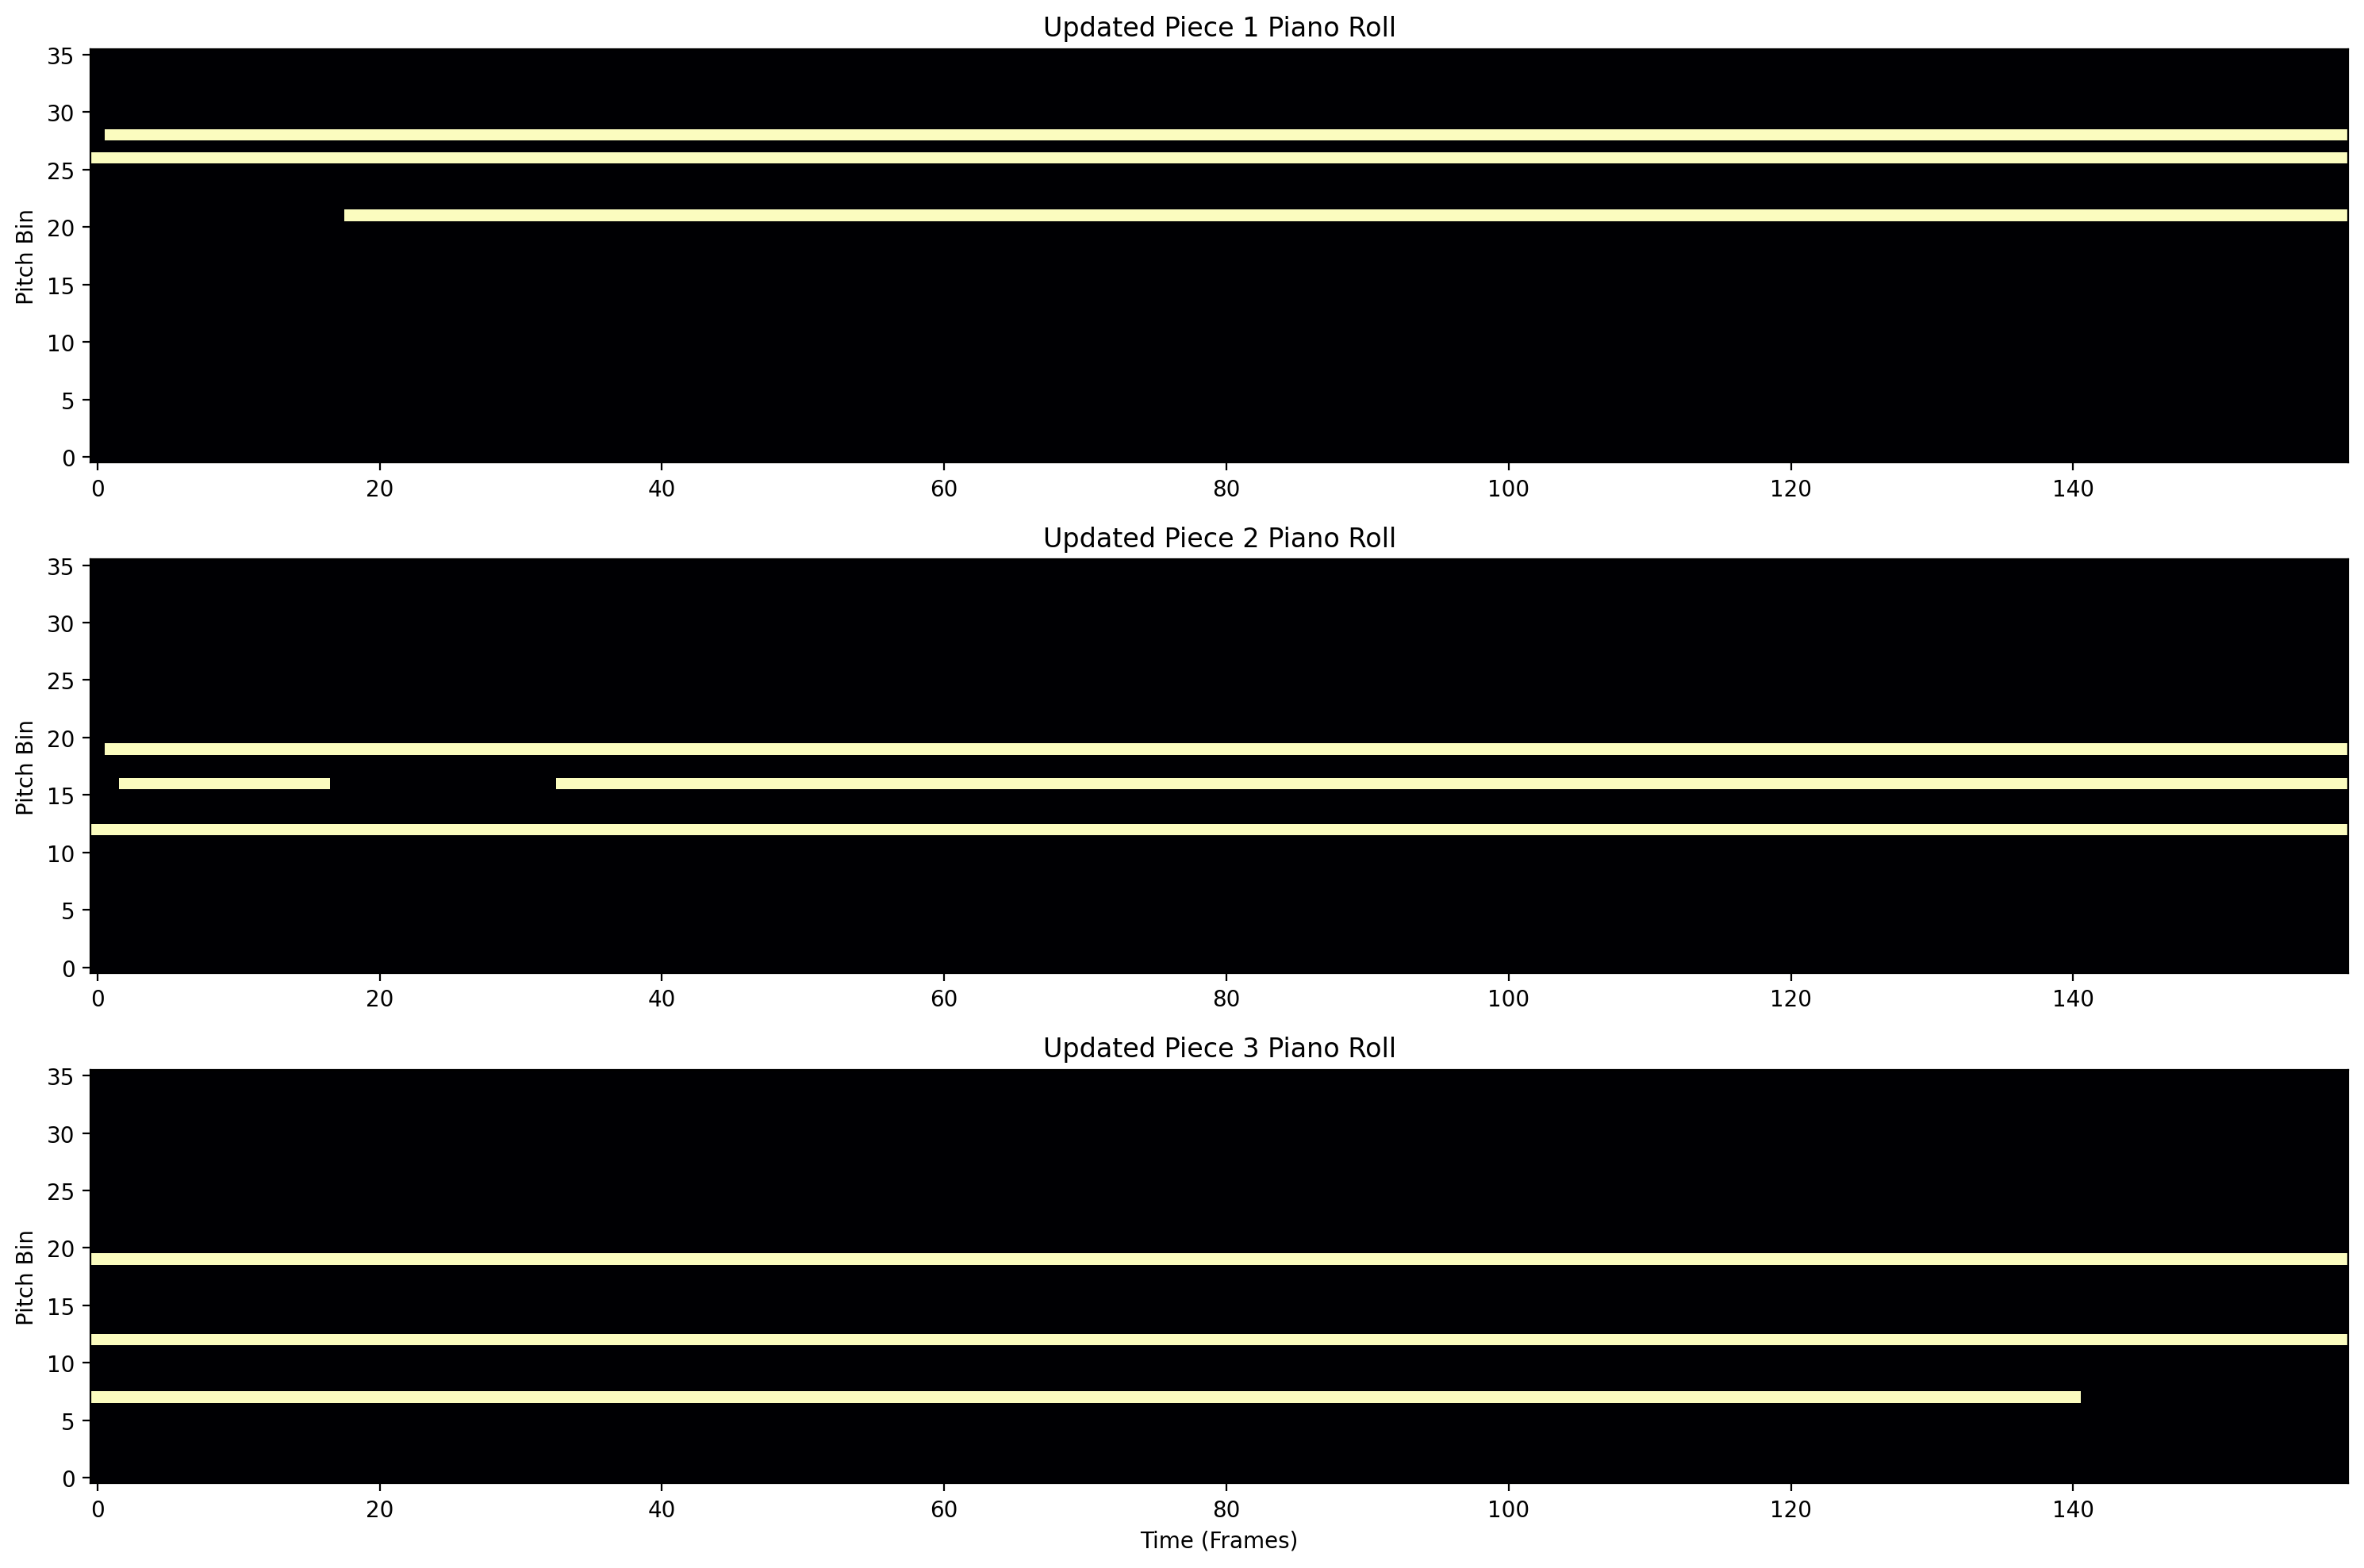

In [ ]:
import matplotlib.pyplot as plt

# Visualize the updated generated piano rolls
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
for i in range(3):
    axes[i].imshow(generated_rolls[i].T, aspect='auto', origin='lower', cmap='magma')
    axes[i].set_title(f'Updated Piece {i+1} Piano Roll')
    axes[i].set_ylabel('Pitch Bin')
plt.xlabel('Time (Frames)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Final Testing on Official Test Split ──
print("Loading official 'test' split for final evaluation...")
test_data = load_split('test', limit=20)
test_loader = DataLoader(TensorDataset(test_data), batch_size=64)

model.eval()
test_loss = 0
with torch.no_grad():
    for (batch,) in test_loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f"\nFinal Test Loss (MSE on official test files): {avg_test_loss:.6f}")

Loading official 'test' split for final evaluation...


Processing test: 100%|██████████| 20/20 [00:16<00:00,  1.21it/s]



Final Test Loss (MSE on official test files): 0.098549


Plot saved as loss_plot.pdf


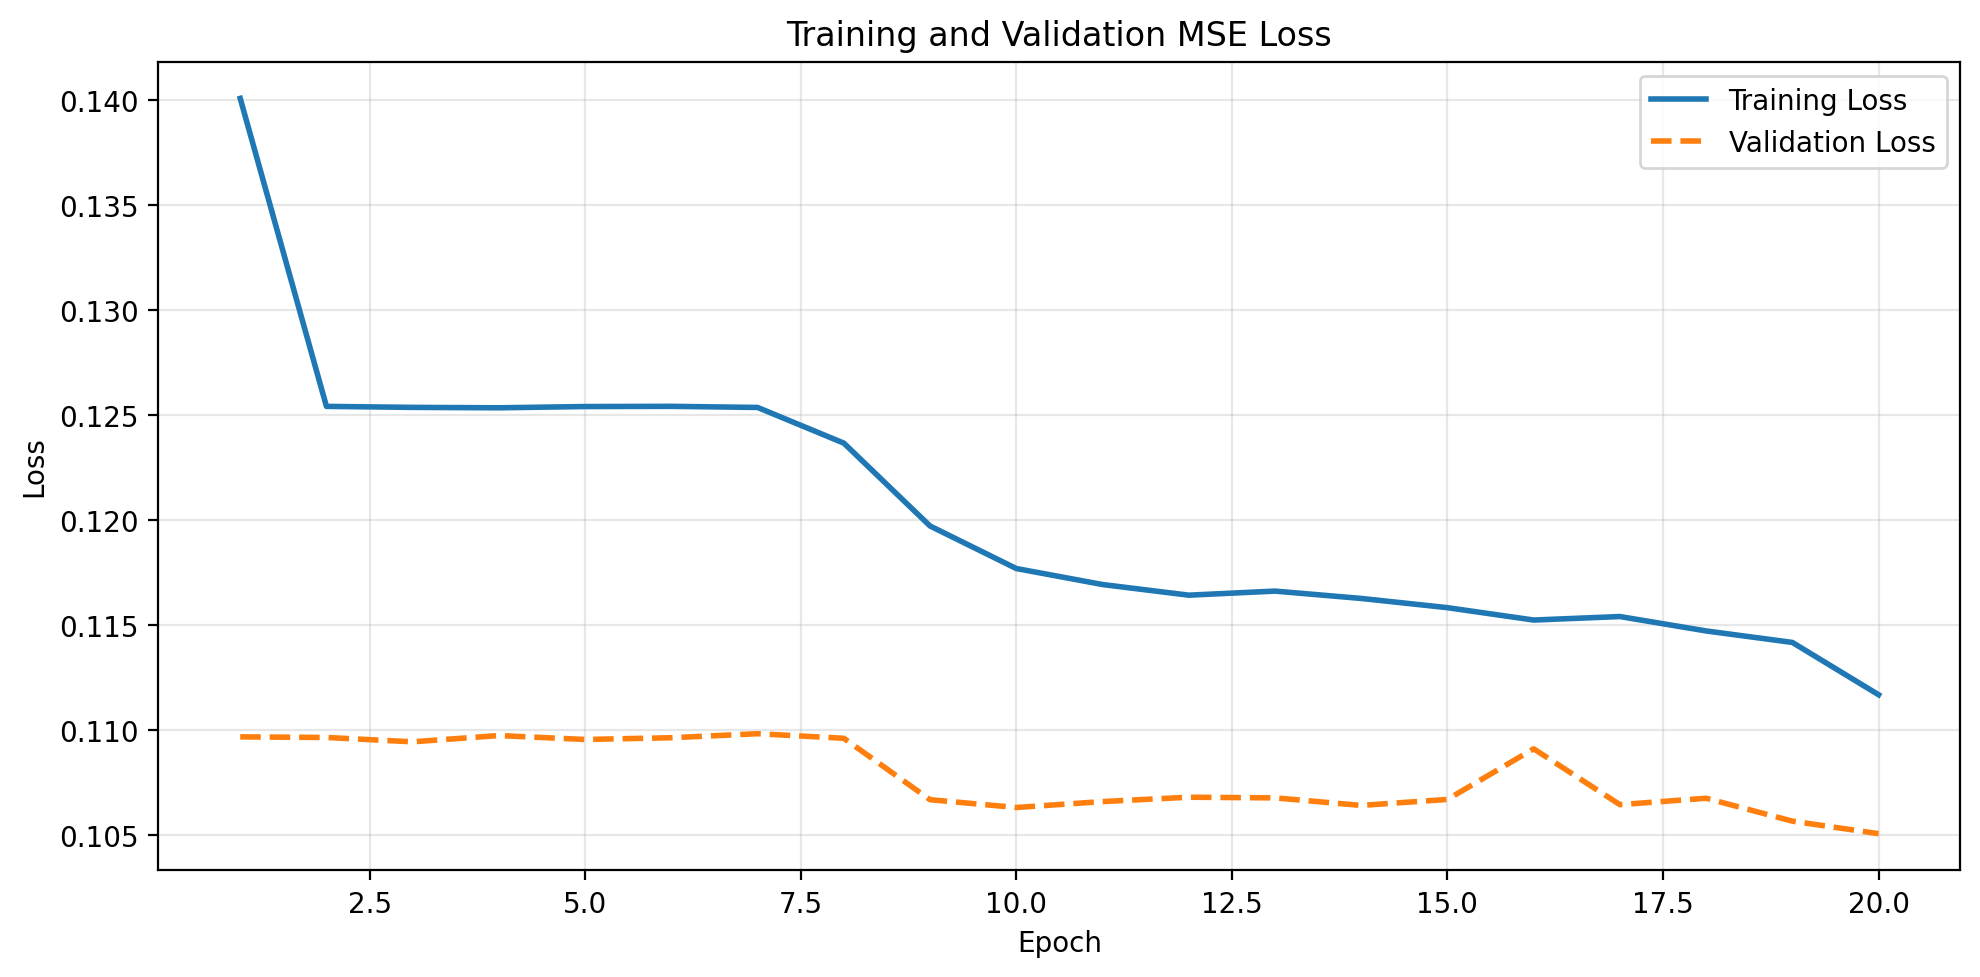

In [ ]:
# ── Plot Training vs Validation Loss and Save as PDF ──
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_history, label='Training Loss', linestyle='-', linewidth=2)
plt.plot(range(1, EPOCHS + 1), val_history, label='Validation Loss', linestyle='--', linewidth=2)

plt.title('Training and Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save as PDF
plt.savefig('loss_plot.pdf')
print("Plot saved as loss_plot.pdf")

plt.show()